In [2]:
import sys
print(sys.executable)

c:\Users\hp\credit-card-fraud-ai\venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything is working 🎉")

Everything is working 🎉


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [5]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [6]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
df.shape


(284807, 31)

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## Dataset Overview

- Total transactions: 284,807
- Total columns: 31
- Target column: `Class`
- Features: `Time`, `V1`–`V28`, `Amount`
- No missing values are present.
- Most features are `float64` because they were transformed using PCA.
- `Class` is an `int64` binary label (0 = legitimate, 1 = fraud).
- Dataset size in memory: ~67.4 MB.

In [9]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

## Class Distribution

The dataset is highly imbalanced.

- Legitimate transactions (Class = 0): 284,315 (99.83%)
- Fraudulent transactions (Class = 1): 492 (0.17%)

This imbalance means that accuracy alone is not an appropriate evaluation metric. Metrics such as Precision, Recall, F1-score, and ROC-AUC will be more suitable for evaluating fraud detection models.

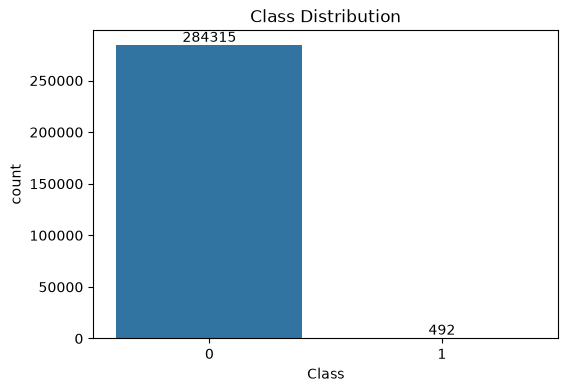

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("../data/raw/creditcard.csv")
plt.figure(figsize=(6,4))
ax = sns.countplot(x="Class", data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Distribution")
plt.show()

In [12]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

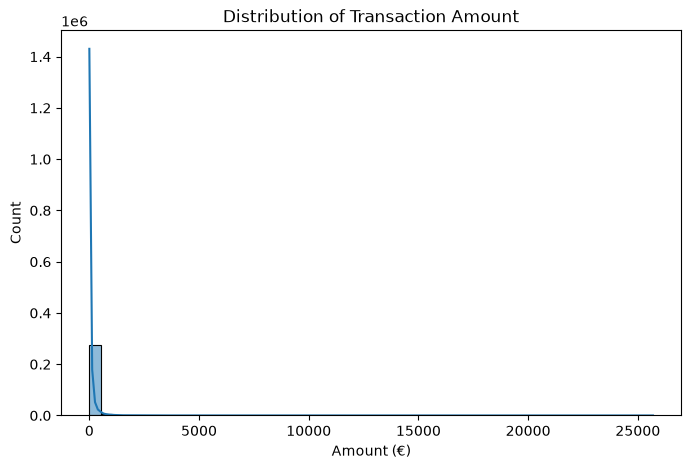

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=50, kde=True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount (€)")
plt.show()

In [14]:
df.duplicated().sum()

np.int64(1081)

In [15]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 1081


## Removing Duplicate Records

The dataset contains duplicate transactions that can bias the machine learning model. These duplicate records are removed to ensure the model learns from unique observations only.

In [16]:
df = df.drop_duplicates()

print(df.shape)

(283726, 31)


In [17]:
df.duplicated().sum()

np.int64(0)

### Observation

A total of **1,081 duplicate transactions** were found and removed from the dataset.

Removing duplicate observations prevents the model from learning repeated patterns and helps produce more reliable evaluation metrics.

## Time Feature Analysis

The `Time` feature represents the number of seconds elapsed between each transaction and the first transaction in the dataset.

In this section, we analyze the distribution of transaction times to understand how transactions are spread throughout the observation period.

In [18]:
df["Time"].describe()

count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64

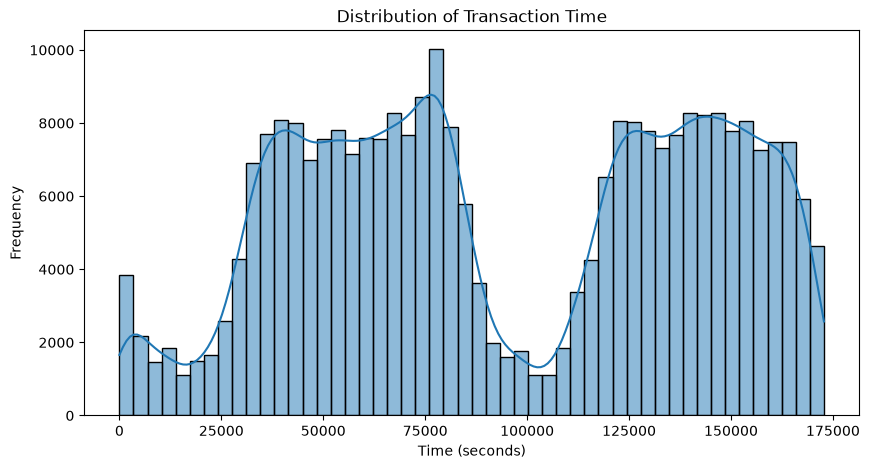

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"], bins=50, kde=True)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency")

plt.show()

### Observation

- The `Time` feature ranges from **0** to approximately **172,792 seconds** (around 48 hours).
- Transactions are distributed continuously throughout the observation period.
- The histogram shows two major peaks, indicating varying transaction activity across the two-day collection period.
- No major missing intervals are observed.
- The `Time` feature may become more useful after feature engineering, such as extracting hours or dividing transactions into time intervals.

# Amount Feature Analysis

The `Amount` feature represents the monetary value of each transaction.

This section analyzes the distribution of transaction amounts, identifies outliers, and evaluates whether the feature requires scaling before model training.

In [20]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

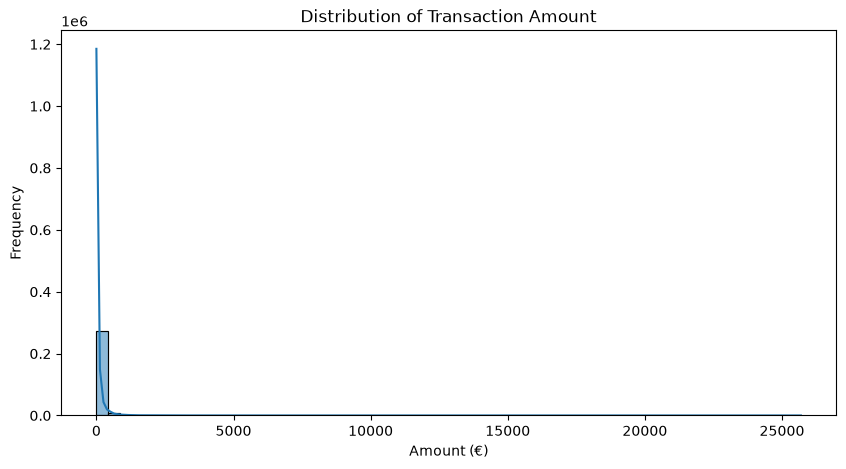

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=60, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount (€)")
plt.ylabel("Frequency")

plt.show()

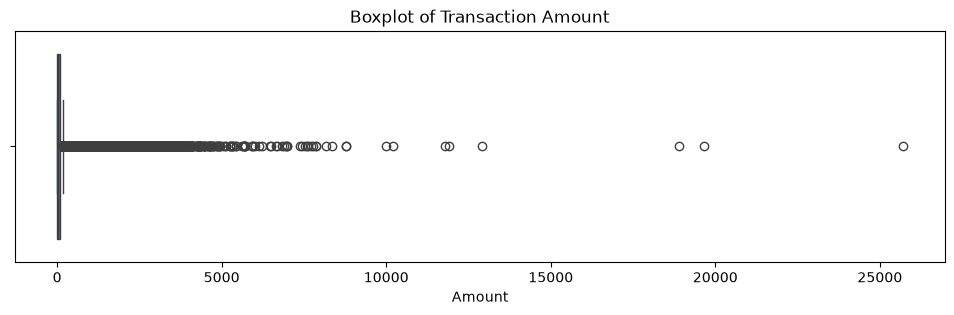

In [22]:
plt.figure(figsize=(12,3))

sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")

plt.show()

In [23]:
df["Amount"].skew()

np.float64(16.978803370060476)

In [24]:
df["Amount"].quantile([0.25,0.50,0.75,0.90,0.95,0.99])

0.25       5.6000
0.50      22.0000
0.75      77.5100
0.90     203.3800
0.95     365.3375
0.99    1018.9650
Name: Amount, dtype: float64

### Observation

- The `Amount` feature is highly right-skewed, with a skewness value of approximately **16.98**.
- Most transactions involve relatively small amounts, while a few transactions have extremely large values.
- The median transaction amount is **€22**, whereas the maximum transaction amount exceeds **€25,000**, indicating the presence of significant outliers.
- According to the percentiles:
  - 25% of transactions are below **€5.60**
  - 50% are below **€22**
  - 75% are below **€77.51**
  - 99% are below approximately **€1019**
- The histogram confirms that the majority of transactions are concentrated near lower values with a long right tail.
- The boxplot clearly shows numerous high-value outliers.
- Since the `Amount` feature has a much larger scale than the PCA-transformed features (`V1`–`V28`), it will require scaling before training machine learning models.

# Outlier Analysis

Outliers are observations that differ significantly from the majority of the data.

In financial datasets, outliers are common because a small number of transactions may involve unusually large amounts. Detecting outliers helps us understand the data distribution and decide whether any preprocessing techniques are required before training machine learning models.

Since the features `V1`–`V28` have already been transformed using PCA, this analysis focuses primarily on the `Amount` and `Time` features.

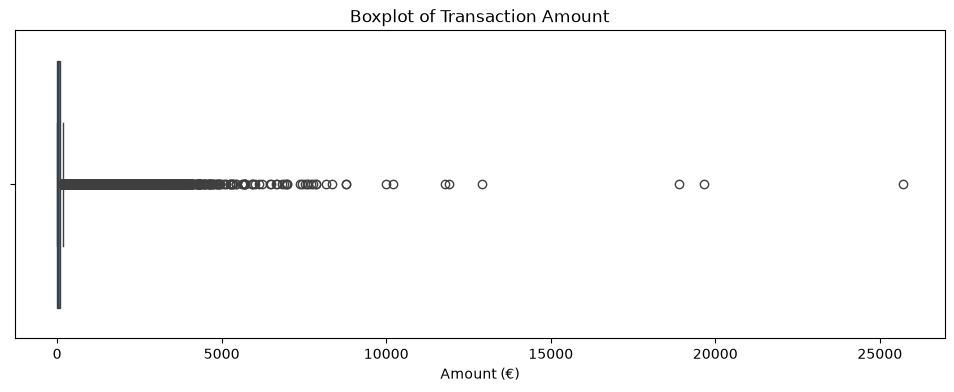

In [25]:
plt.figure(figsize=(12,4))

sns.boxplot(x=df["Amount"])

plt.title("Boxplot of Transaction Amount")

plt.xlabel("Amount (€)")

plt.show()

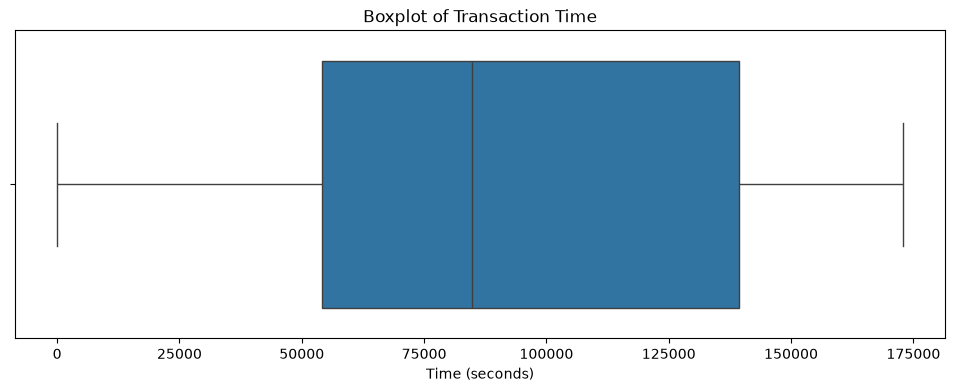

In [26]:
plt.figure(figsize=(12,4))

sns.boxplot(x=df["Time"])

plt.title("Boxplot of Transaction Time")

plt.xlabel("Time (seconds)")

plt.show()

In [27]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -102.26500000000001
Upper Bound: 185.375


In [28]:
amount_outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Number of Outliers:", amount_outliers.shape[0])

Number of Outliers: 31685


In [29]:
outlier_percentage = (amount_outliers.shape[0] / len(df)) * 100

print(f"Percentage of Outliers: {outlier_percentage:.2f}%")

Percentage of Outliers: 11.17%


### Observation

- The `Amount` feature contains a considerable number of outliers.
- Most transactions involve relatively small amounts, while a small number of transactions have extremely high values.
- These outliers are expected in real-world financial datasets and may represent legitimate high-value purchases as well as potentially suspicious transactions.
- Therefore, the outliers should **not** be removed at this stage because they may contain valuable information for fraud detection.
- Instead of removing them, appropriate feature scaling techniques such as **RobustScaler** or **StandardScaler** will be considered during preprocessing.

# Fraud vs Normal Transaction Comparison

To better understand the differences between fraudulent and legitimate transactions, we compare the distribution of transaction amounts between the two classes.

This comparison helps us determine whether fraudulent transactions generally involve larger or smaller amounts and whether the two classes follow different spending patterns.

In [30]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

print("Normal Transactions:", normal.shape[0])
print("Fraud Transactions:", fraud.shape[0])

Normal Transactions: 283253
Fraud Transactions: 473


## Summary Statistics

The descriptive statistics below compare transaction amounts for fraudulent and normal transactions.

In [31]:
normal["Amount"].describe()

count    283253.000000
mean         88.413575
std         250.379023
min           0.000000
25%           5.670000
50%          22.000000
75%          77.460000
max       25691.160000
Name: Amount, dtype: float64

In [32]:
fraud["Amount"].describe()

count     473.000000
mean      123.871860
std       260.211041
min         0.000000
25%         1.000000
50%         9.820000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

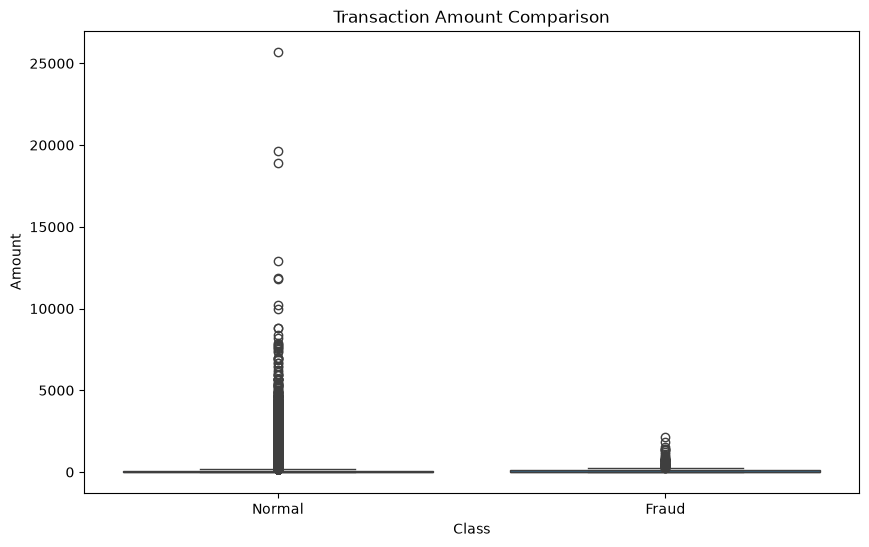

In [33]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df
)

plt.xticks([0,1],["Normal","Fraud"])

plt.title("Transaction Amount Comparison")

plt.show()

### Observation

- Normal transactions show a wider range of transaction amounts.
- Fraudulent transactions are generally concentrated within lower transaction values.
- Both classes contain outliers, although legitimate transactions exhibit much larger extreme values.

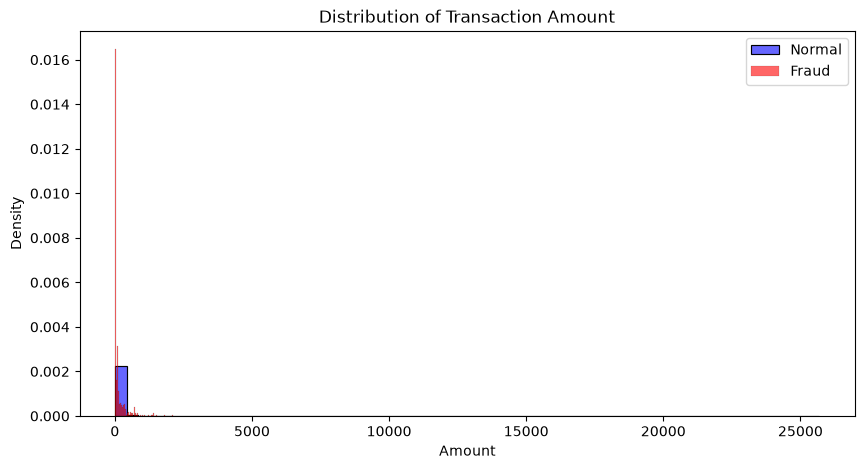

In [34]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=normal,
    x="Amount",
    bins=60,
    color="blue",
    label="Normal",
    stat="density",
    alpha=0.6
)

sns.histplot(
    data=fraud,
    x="Amount",
    bins=60,
    color="red",
    label="Fraud",
    stat="density",
    alpha=0.6
)

plt.legend()

plt.title("Distribution of Transaction Amount")

plt.show()

### Observation

- Legitimate transactions occur across a wide range of amounts.
- Fraudulent transactions are more concentrated around smaller transaction values.
- The distributions overlap, indicating that transaction amount alone cannot accurately distinguish fraud.

In [35]:
df.groupby("Class")["Amount"].mean()

Class
0     88.413575
1    123.871860
Name: Amount, dtype: float64

In [36]:
df.groupby("Class")["Amount"].median()

Class
0    22.00
1     9.82
Name: Amount, dtype: float64

### Key Findings

- Fraudulent transactions generally involve lower transaction amounts than legitimate transactions.
- Transaction amount alone is insufficient for fraud detection because significant overlap exists between the two classes.
- This suggests that multiple features must be considered together during model training.

# Correlation Analysis

Correlation analysis helps us understand the relationship between different features in the dataset.

The correlation coefficient ranges from **-1 to +1**:

- **+1** → Perfect positive correlation
- **0** → No correlation
- **-1** → Perfect negative correlation

Since most features in this dataset (`V1` to `V28`) were generated using Principal Component Analysis (PCA), they are expected to exhibit low correlation with one another.

In this section, we visualize feature correlations using a heatmap and identify which variables have the strongest relationship with the target variable (`Class`).

In [37]:
corr_matrix = df.corr()

corr_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,0.031068,-0.248536,0.125500,-0.065958,-0.100316,-0.184392,0.011286,-0.073819,0.090305,0.029537,-0.051022,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559,-0.012359
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,0.000815,0.001028,-0.001524,-0.000568,-0.002663,-0.000602,-0.003345,-0.003491,-0.003535,0.000919,-0.001393,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105,-0.094486
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,0.000620,-0.000633,0.002266,0.000680,0.002711,0.001538,0.004013,0.003244,0.002477,-0.000358,-0.001287,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428,0.084624
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,-0.009632,0.002339,-0.005900,0.000113,-0.003027,-0.001230,-0.004430,-0.008159,-0.003495,-0.000016,-0.002269,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410,-0.182322
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,0.002753,-0.001223,0.003366,0.000177,0.002801,0.000572,0.003346,0.003655,0.002325,-0.000560,0.000318,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514,0.129326


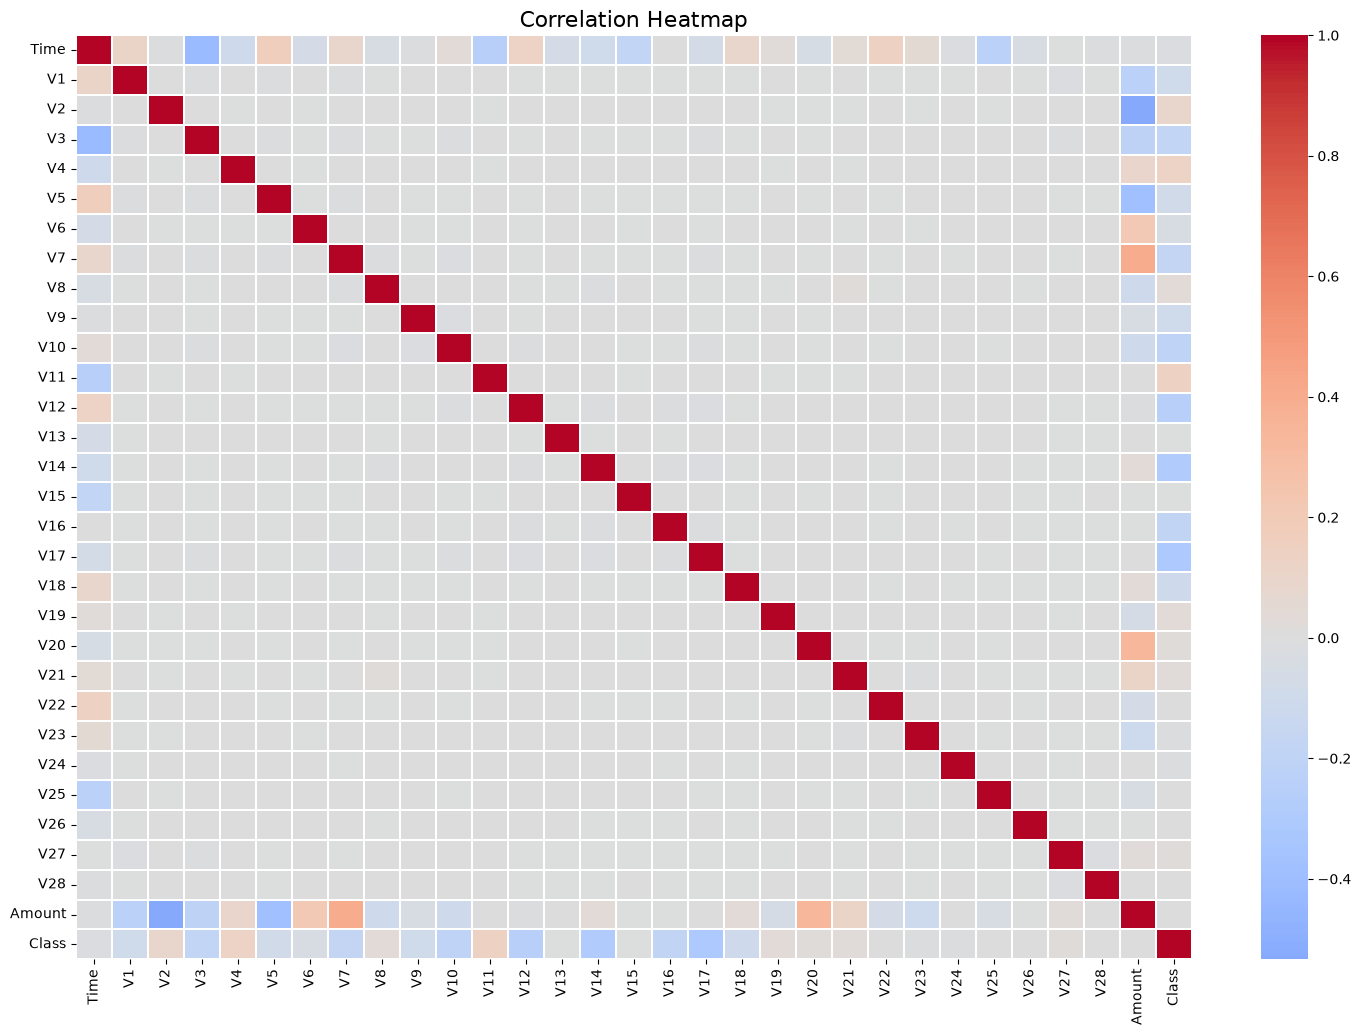

In [38]:
plt.figure(figsize=(18,12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

### Observation

- Most features exhibit very weak correlation with one another.
- This is expected because the features (`V1`–`V28`) are transformed using Principal Component Analysis (PCA).
- No severe multicollinearity is observed among the predictor variables.
- The target variable (`Class`) appears to have meaningful correlation with only a few features.

## Correlation of Features with Fraud Class

To better understand which variables contribute to fraud detection, we compute the correlation of every feature with the target variable (`Class`).

Sorting these values allows us to identify the strongest positive and negative relationships.

In [39]:
class_corr = corr_matrix["Class"].sort_values(ascending=False)

class_corr

Class     1.000000
V11       0.149067
V4        0.129326
V2        0.084624
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
V28       0.009682
Amount    0.005777
V22       0.004887
V26       0.004265
V25       0.003202
V15      -0.003300
V13      -0.003897
V23      -0.006333
V24      -0.007210
Time     -0.012359
V6       -0.043915
V5       -0.087812
V9       -0.094021
V1       -0.094486
V18      -0.105340
V7       -0.172347
V3       -0.182322
V16      -0.187186
V10      -0.206971
V12      -0.250711
V14      -0.293375
V17      -0.313498
Name: Class, dtype: float64

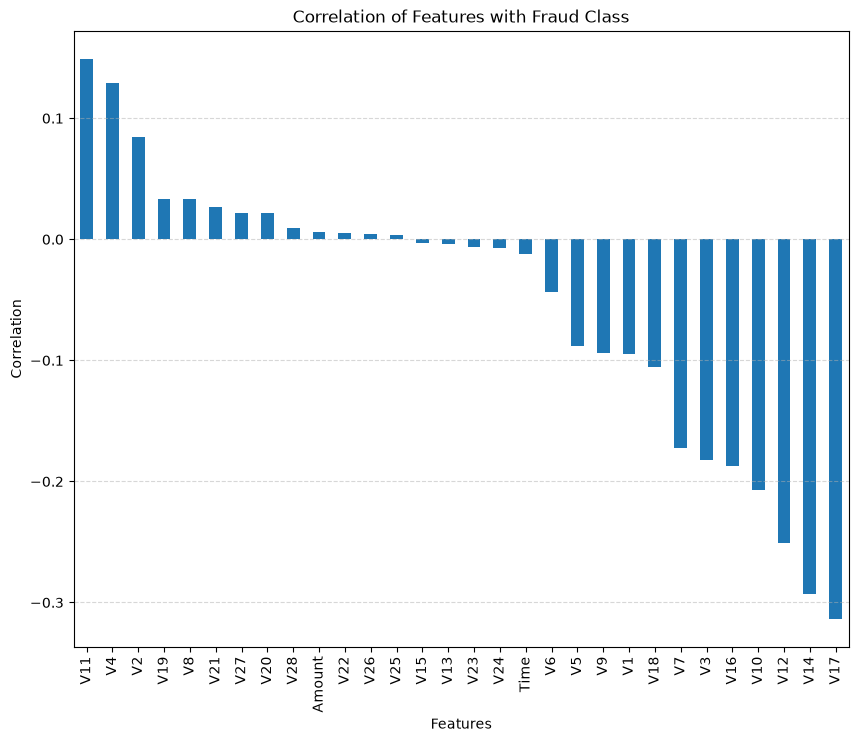

In [40]:
plt.figure(figsize=(10,8))

class_corr.drop("Class").plot(kind="bar")

plt.title("Correlation of Features with Fraud Class")

plt.xlabel("Features")

plt.ylabel("Correlation")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Observation

- Some features show positive correlation with fraudulent transactions, while others show negative correlation.
- Features with larger absolute correlation values are likely to contribute more toward distinguishing fraudulent and genuine transactions.
- Most features have relatively small correlation values, indicating that fraud detection depends on the combined effect of multiple variables rather than a single feature.

In [41]:
class_corr.head(10)

Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64

In [42]:
class_corr.tail(10)

V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64

### Key Findings

The features with the strongest positive and negative correlation with the target variable may carry valuable information for fraud detection.

However, correlation alone does not determine feature importance. Machine learning models can capture complex nonlinear relationships that are not reflected by simple correlation coefficients.

# EDA Summary

The exploratory data analysis revealed several important characteristics of the dataset:

- The dataset contains **283,726 unique transactions** after removing duplicate records.
- No missing values were found, indicating that the dataset is complete and ready for further processing.
- The target variable is highly imbalanced, with fraudulent transactions representing less than **0.2%** of all observations.
- The `Amount` feature is heavily right-skewed and contains numerous outliers, which is expected in real-world financial transaction data.
- The `Time` feature spans approximately **48 hours** and shows continuous transaction activity throughout the observation period.
- Fraudulent transactions generally involve lower transaction amounts compared to legitimate transactions, although significant overlap exists between the two classes.
- Correlation analysis indicates that no single feature is sufficient for fraud detection, highlighting the importance of combining multiple variables during model training.
- Since the dataset is highly imbalanced, evaluation metrics such as **Precision, Recall, F1-score, Precision-Recall AUC, and ROC-AUC** will be more informative than overall accuracy.
- The next phase involves preprocessing the data by scaling numerical features, splitting the dataset into training and testing sets, and handling class imbalance before model training.

# Model Training

In this section, we prepare the dataset for machine learning by separating features and labels, splitting the data into training and testing sets, and applying feature scaling where necessary.

In [43]:
X = df.drop("Class", axis=1)
y = df["Class"]
print(X.shape)
print(y.shape)


(283726, 30)
(283726,)


In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(226980, 30)
(56746, 30)
(226980,)
(56746,)


In [46]:
print(y_train.value_counts(normalize=True) * 100)
print()

print(y_test.value_counts(normalize=True) * 100)

Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [54]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9991188806259472
Precision: 0.8461538461538461
Recall   : 0.5789473684210527
F1 Score : 0.6875
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746

[[56641    10]
 [   40    55]]


## Model Evaluation Summary

The first baseline model was trained using **Logistic Regression** after completing data preprocessing, including duplicate removal, train-test split, and feature scaling using `StandardScaler`.

### Results

- **Accuracy:** 99.91%
- **Precision:** 84.62%
- **Recall:** 57.89%
- **F1 Score:** 68.75%

### Observations

- The model achieved very high overall accuracy due to the highly imbalanced nature of the dataset.
- A precision of approximately **85%** indicates that when the model predicts a transaction as fraudulent, it is usually correct.
- However, the recall of **58%** shows that the model still misses a significant number of fraudulent transactions.
- In fraud detection, **recall is often more important than accuracy**, since failing to detect fraudulent transactions can have serious financial consequences.
- Logistic Regression serves as a strong baseline model. More advanced models such as **Random Forest** and **XGBoost** will be evaluated to improve fraud detection performance.

### Conclusion

This baseline model provides a solid starting point. The next step is to compare its performance with tree-based models and explore techniques for handling class imbalance to improve recall while maintaining high precision.

# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Unlike Logistic Regression, Random Forest does not require feature scaling because it makes decisions by splitting feature values rather than calculating distances.

In this section, we train a Random Forest classifier and compare its performance with the baseline Logistic Regression model.

In [56]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    8.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   35.2s finished


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None


In [63]:
rf_pred = rf.predict(X_test)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.1s finished


In [65]:
print(accuracy_score(y_test, rf_pred))
print(precision_score(y_test, rf_pred))
print(recall_score(y_test, rf_pred))
print(f1_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

0.9995065731505305
0.971830985915493
0.7263157894736842
0.8313253012048193
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746

[[56649     2]
 [   26    69]]


## Model Comparison

The Random Forest classifier outperformed the baseline Logistic Regression model across all evaluation metrics.

### Logistic Regression
- Accuracy: 99.91%
- Precision: 84.62%
- Recall: 57.89%
- F1 Score: 68.75%

### Random Forest
- Accuracy: 99.95%
- Precision: 97.18%
- Recall: 72.63%
- F1 Score: 83.13%

### Observation

Random Forest detected significantly more fraudulent transactions while also reducing false alarms.

The confusion matrix shows that Random Forest decreased false negatives from 40 to 26 and false positives from 10 to 2, making it a much stronger baseline model for credit card fraud detection.

Based on these results, Random Forest is selected as the preferred baseline model for the next stages of the project.